In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [5]:
df = pd.read_csv('data.csv')    
df.shape

(217811, 27)

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Security,GICS Sector,...,News - Analyst Comments,News - Stocks,News - Dividends,News - Corporate Earnings,News - Mergers & Acquisitions,News - Store Openings,News - Product Recalls,News - Adverse Events,News - Personnel Changes,News - Stock Rumors
0,2020-09-30,160.929993,163.100006,158.610001,160.179993,150.921692,3056900.0,MMM,3M,Industrials,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-10-01,160.669998,161.899994,157.720001,158.789993,149.612045,1989100.0,MMM,3M,Industrials,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-10-02,156.470001,161.940002,156.250000,160.360001,151.091309,1768600.0,MMM,3M,Industrials,...,2.0,2.0,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0
3,2020-10-05,162.250000,163.500000,161.759995,162.750000,153.343170,1457000.0,MMM,3M,Industrials,...,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0
4,2020-10-06,163.440002,165.699997,161.830002,162.229996,152.853195,2021900.0,MMM,3M,Industrials,...,3.0,3.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217811 entries, 0 to 217810
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           217811 non-null  object 
 1   Open                           217811 non-null  float64
 2   High                           217811 non-null  float64
 3   Low                            217811 non-null  float64
 4   Close                          217811 non-null  float64
 5   Adj Close                      217811 non-null  float64
 6   Volume                         217811 non-null  float64
 7   Symbol                         217811 non-null  object 
 8   Security                       217811 non-null  object 
 9   GICS Sector                    217811 non-null  object 
 10  GICS Sub-Industry              217811 non-null  object 
 11  News - All News Volume         217318 non-null  float64
 12  News - Volume                 

In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,News - All News Volume,News - Volume,News - Positive Sentiment,News - Negative Sentiment,...,News - Analyst Comments,News - Stocks,News - Dividends,News - Corporate Earnings,News - Mergers & Acquisitions,News - Store Openings,News - Product Recalls,News - Adverse Events,News - Personnel Changes,News - Stock Rumors
count,217811.000000,217811.000000,217811.000000,217811.000000,217811.000000,2.178110e+05,217318.000000,217318.000000,217318.000000,217318.000000,...,217318.000000,217318.000000,217318.000000,217318.000000,217318.000000,217318.000000,217318.000000,217318.000000,217318.000000,217318.000000
mean,183.600141,185.897898,181.191176,183.536161,181.850304,4.879334e+06,522589.153103,84.601354,4.340680,3.788526,...,10.458908,11.294044,0.475985,3.557598,2.116461,0.081530,0.119903,4.243008,0.802165,0.005029
std,318.940358,322.924940,314.740126,318.819043,318.763859,1.077616e+07,49863.993488,246.619349,28.298986,16.033536,...,31.119464,32.588282,2.353701,15.605966,11.248249,0.970355,3.310985,18.069263,6.864593,0.100878
min,3.810000,3.990000,3.730000,3.850000,3.750584,6.000000e+02,317745.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,59.509998,60.270000,58.770000,59.500000,58.074932,8.996000e+05,494005.000000,11.000000,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,111.949997,113.360001,110.410004,111.910004,110.048462,1.880400e+06,531109.000000,24.000000,0.000000,0.000000,...,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,206.720001,209.100006,204.289993,206.729996,204.220001,4.382900e+06,558752.000000,58.000000,1.000000,1.000000,...,10.000000,11.000000,0.000000,3.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000
max,5977.609863,5982.450195,5884.060059,5959.330078,5959.330078,3.270974e+08,669851.000000,9769.000000,4550.000000,1182.000000,...,842.000000,858.000000,173.000000,772.000000,1388.000000,93.000000,599.000000,1679.000000,1686.000000,12.000000


In [7]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
# Since the dataset can contain multiple stocks, we will build a model for one.
# Let's filter for 'MMM' stock. You can change 'MMM' to any other symbol.
df_stock = df[df['Symbol'] == 'MMM'].copy()

In [9]:
# Sort the dataframe by date, which is crucial for time series data
df_stock.sort_values('Date', inplace=True)
df_stock.reset_index(drop=True, inplace=True)

In [11]:
df.isnull().sum()

Date                               0
Open                               0
High                               0
Low                                0
Close                              0
Adj Close                          0
Volume                             0
Symbol                             0
Security                           0
GICS Sector                        0
GICS Sub-Industry                  0
News - All News Volume           493
News - Volume                    493
News - Positive Sentiment        493
News - Negative Sentiment        493
News - New Products              493
News - Layoffs                   493
News - Analyst Comments          493
News - Stocks                    493
News - Dividends                 493
News - Corporate Earnings        493
News - Mergers & Acquisitions    493
News - Store Openings            493
News - Product Recalls           493
News - Adverse Events            493
News - Personnel Changes         493
News - Stock Rumors              493
d

In [12]:
df_stock

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Security,GICS Sector,...,News - Analyst Comments,News - Stocks,News - Dividends,News - Corporate Earnings,News - Mergers & Acquisitions,News - Store Openings,News - Product Recalls,News - Adverse Events,News - Personnel Changes,News - Stock Rumors
0,2020-09-30,160.929993,163.100006,158.610001,160.179993,150.921692,3056900.0,MMM,3M,Industrials,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-10-01,160.669998,161.899994,157.720001,158.789993,149.612045,1989100.0,MMM,3M,Industrials,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-10-02,156.470001,161.940002,156.250000,160.360001,151.091309,1768600.0,MMM,3M,Industrials,...,2.0,2.0,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0
3,2020-10-05,162.250000,163.500000,161.759995,162.750000,153.343170,1457000.0,MMM,3M,Industrials,...,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0
4,2020-10-06,163.440002,165.699997,161.830002,162.229996,152.853195,2021900.0,MMM,3M,Industrials,...,3.0,3.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,2022-06-24,131.529999,134.550003,131.240005,134.330002,134.330002,3659300.0,MMM,3M,Industrials,...,10.0,10.0,0.0,0.0,2.0,0.0,0.0,5.0,0.0,0.0
437,2022-06-27,134.410004,134.669998,132.289993,132.800003,132.800003,2388600.0,MMM,3M,Industrials,...,5.0,6.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
438,2022-06-28,133.860001,134.570007,130.149994,130.330002,130.330002,2408300.0,MMM,3M,Industrials,...,7.0,7.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0
439,2022-06-29,130.000000,130.339996,128.809998,129.770004,129.770004,2821100.0,MMM,3M,Industrials,...,8.0,9.0,2.0,1.0,3.0,0.0,0.0,5.0,0.0,0.0


In [10]:
# Fill missing values in sentiment columns with 0
sentiment_cols = [col for col in df.columns if 'News -' in col]
df_stock[sentiment_cols] = df_stock[sentiment_cols].fillna(0)

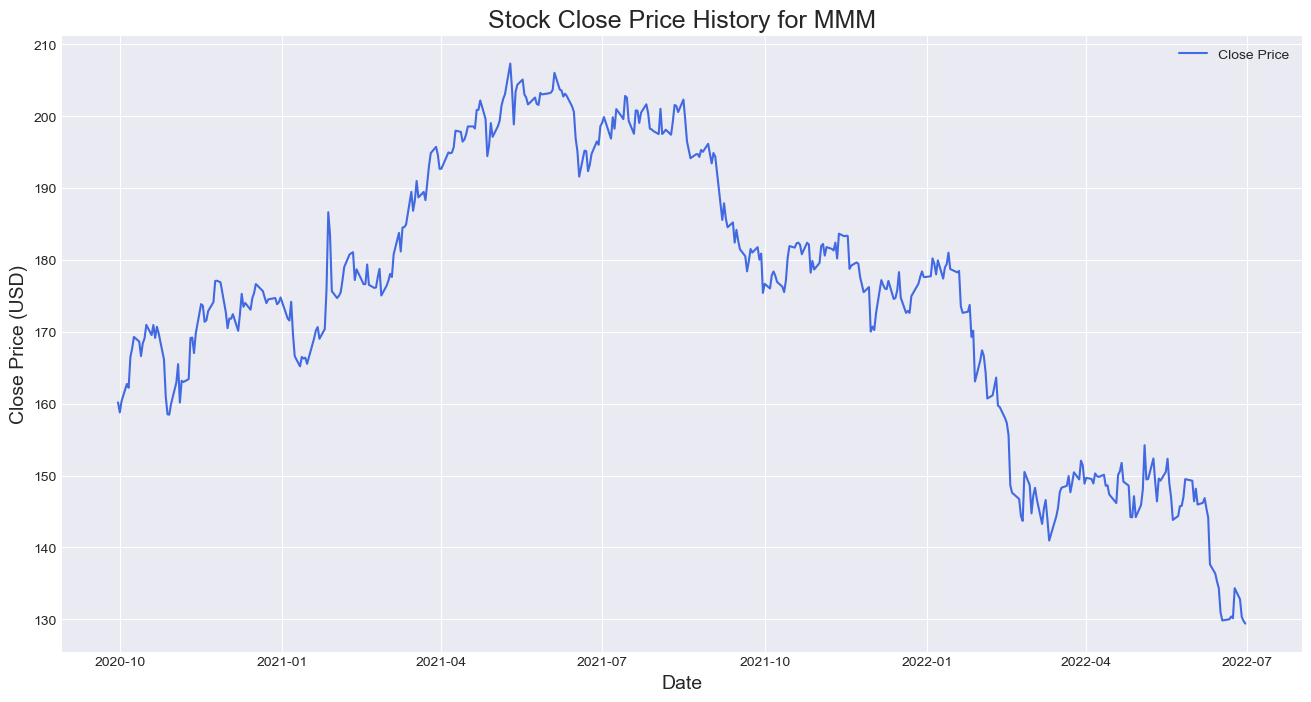

In [13]:
plt.style.use('seaborn-v0_8-darkgrid')
# Plot Closing Price History
plt.figure(figsize=(16, 8))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price', color='royalblue')
plt.title(f'Stock Close Price History for {df_stock["Symbol"].iloc[0]}', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price (USD)', fontsize=14)
plt.legend()
plt.show()

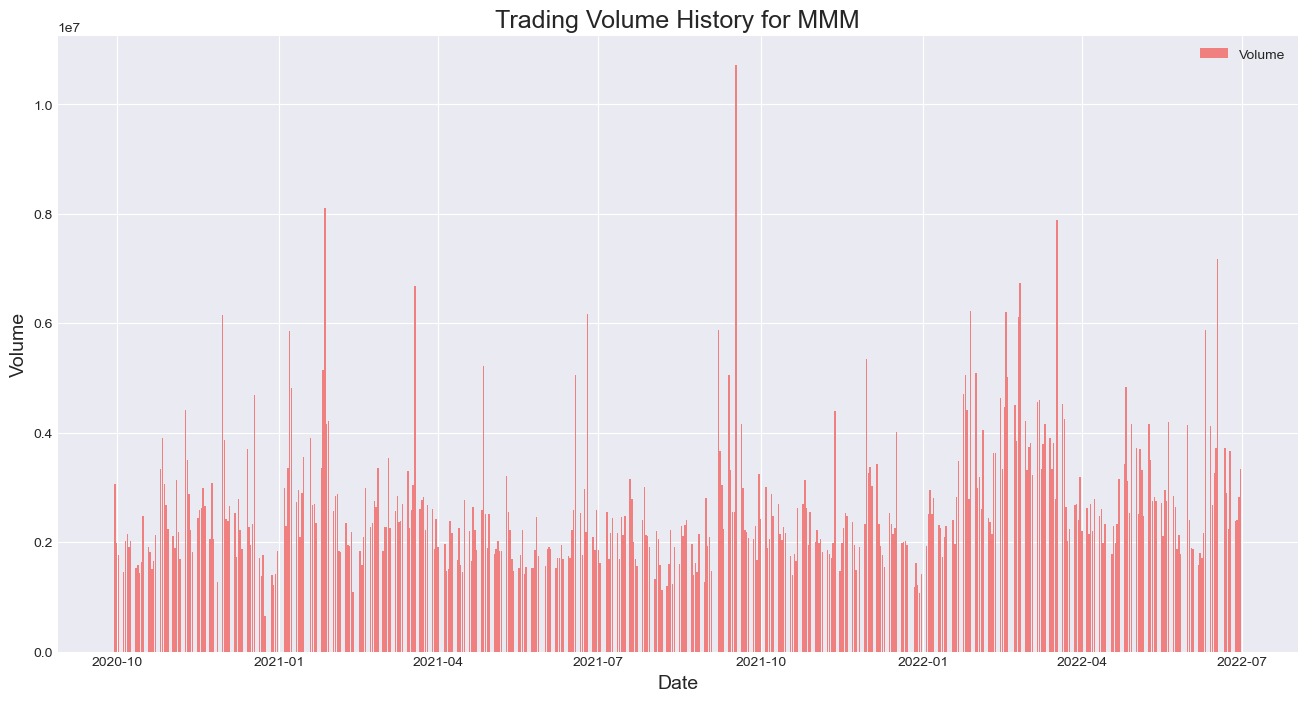

In [14]:
plt.figure(figsize=(16, 8))
plt.bar(df_stock['Date'], df_stock['Volume'], label='Volume', color='lightcoral')
plt.title(f'Trading Volume History for {df_stock["Symbol"].iloc[0]}', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Volume', fontsize=14)
plt.legend()
plt.show()

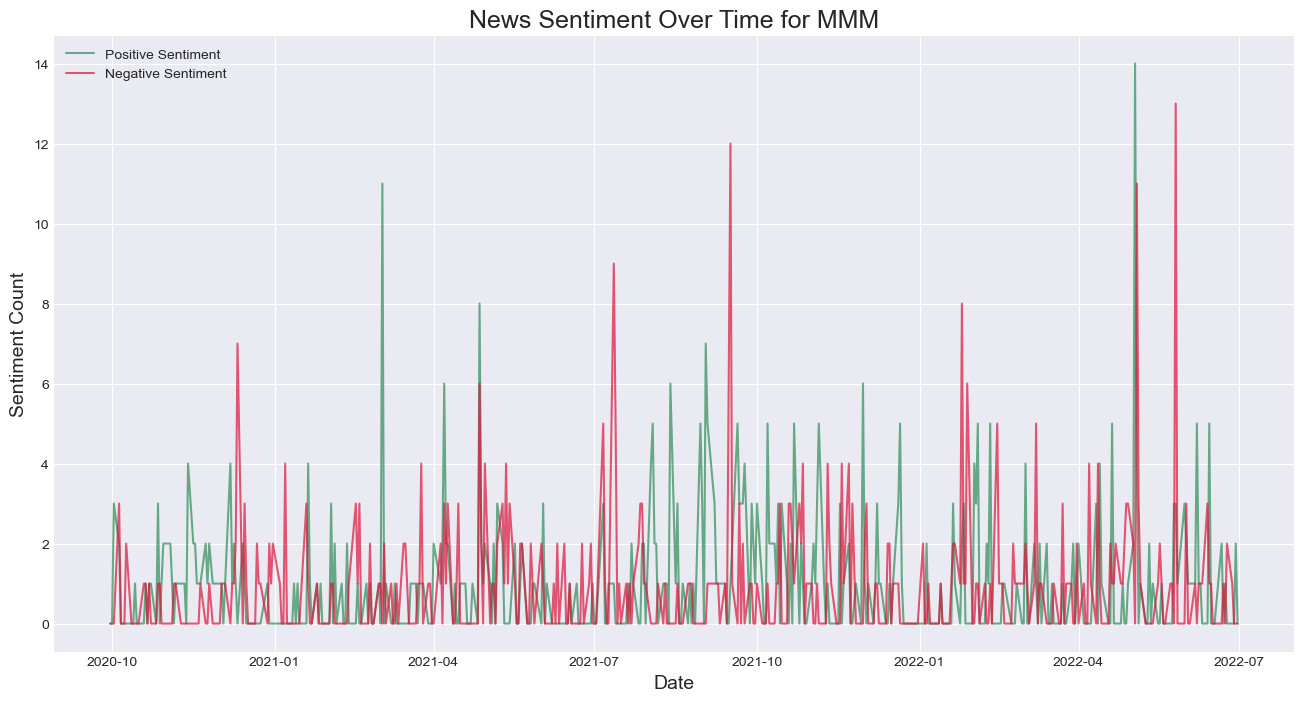

In [15]:
# Plot Positive vs. Negative Sentiment
plt.figure(figsize=(16, 8))
plt.plot(df_stock['Date'], df_stock['News - Positive Sentiment'], label='Positive Sentiment', color='seagreen', alpha=0.7)
plt.plot(df_stock['Date'], df_stock['News - Negative Sentiment'], label='Negative Sentiment', color='crimson', alpha=0.7)
plt.title(f'News Sentiment Over Time for {df_stock["Symbol"].iloc[0]}', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sentiment Count', fontsize=14)
plt.legend()
plt.show()

In [16]:
# Create time-based features
df_stock['Year'] = df_stock['Date'].dt.year
df_stock['Month'] = df_stock['Date'].dt.month
df_stock['Day'] = df_stock['Date'].dt.day
df_stock['DayOfWeek'] = df_stock['Date'].dt.dayofweek


In [17]:
# Create Lag Features (previous day's close)
df_stock['Lag_1_Close'] = df_stock['Close'].shift(1)


In [18]:
# Create Moving Averages
df_stock['MA_7'] = df_stock['Close'].rolling(window=7).mean()
df_stock['MA_30'] = df_stock['Close'].rolling(window=30).mean()

In [19]:
# Create Rolling Volatility
df_stock['Volatility_7'] = df_stock['Close'].rolling(window=7).std()

In [20]:
epsilon = 1e-6
df_stock['Positive_Sentiment_Ratio'] = df_stock['News - Positive Sentiment'] / (df_stock['News - Volume'] + epsilon)
df_stock['Negative_Sentiment_Ratio'] = df_stock['News - Negative Sentiment'] / (df_stock['News - Volume'] + epsilon)


In [23]:
df_stock.isnull().sum()

Date                             0
Open                             0
High                             0
Low                              0
Close                            0
Adj Close                        0
Volume                           0
Symbol                           0
Security                         0
GICS Sector                      0
GICS Sub-Industry                0
News - All News Volume           0
News - Volume                    0
News - Positive Sentiment        0
News - Negative Sentiment        0
News - New Products              0
News - Layoffs                   0
News - Analyst Comments          0
News - Stocks                    0
News - Dividends                 0
News - Corporate Earnings        0
News - Mergers & Acquisitions    0
News - Store Openings            0
News - Product Recalls           0
News - Adverse Events            0
News - Personnel Changes         0
News - Stock Rumors              0
Year                             0
Month               

In [24]:
# Drop rows with NaN values created by shifts and rolling windows
df_stock.dropna(inplace=True)

In [26]:
df_stock.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Security,GICS Sector,...,Year,Month,Day,DayOfWeek,Lag_1_Close,MA_7,MA_30,Volatility_7,Positive_Sentiment_Ratio,Negative_Sentiment_Ratio
29,2020-11-10,165.190002,169.270004,163.860001,169.139999,159.363800,3500400.0,MMM,3M,Industrials,...,2020,11,10,1,163.429993,163.914285,165.109333,2.782167,0.012987,0.0
30,2020-11-11,170.729996,170.740005,167.600006,169.210007,159.429764,2884400.0,MMM,3M,Industrials,...,2020,11,11,2,169.139999,164.810000,165.410334,3.364571,0.043478,0.0
31,2020-11-12,168.149994,169.190002,165.580002,167.050003,157.394623,2216700.0,MMM,3M,Industrials,...,2020,11,12,3,169.210007,165.030001,165.685667,3.466767,0.000000,0.0
32,2020-11-13,167.919998,170.259995,167.279999,169.789993,159.976257,1812100.0,MMM,3M,Industrials,...,2020,11,13,4,167.050003,166.405714,166.000001,3.103852,0.148148,0.0
33,2020-11-16,172.619995,173.889999,170.179993,173.860001,163.811020,2434300.0,MMM,3M,Industrials,...,2020,11,16,0,169.789993,167.928571,166.370334,3.804811,0.083333,0.0


In [28]:
# Model Preparation & Training

In [29]:
# Define features (X) and target (y)
# We want to predict the 'Close' price
target = 'Close'
# Features are all columns except the target and non-numeric/identifier columns
features = [col for col in df_stock.columns if col not in ['Date', 'Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Close', 'Adj Close']]

X = df_stock[features]
y = df_stock[target]

In [30]:
features

['Open',
 'High',
 'Low',
 'Volume',
 'News - All News Volume',
 'News - Volume',
 'News - Positive Sentiment',
 'News - Negative Sentiment',
 'News - New Products',
 'News - Layoffs',
 'News - Analyst Comments',
 'News - Stocks',
 'News - Dividends',
 'News - Corporate Earnings',
 'News - Mergers & Acquisitions',
 'News - Store Openings',
 'News - Product Recalls',
 'News - Adverse Events',
 'News - Personnel Changes',
 'News - Stock Rumors',
 'Year',
 'Month',
 'Day',
 'DayOfWeek',
 'Lag_1_Close',
 'MA_7',
 'MA_30',
 'Volatility_7',
 'Positive_Sentiment_Ratio',
 'Negative_Sentiment_Ratio']

In [31]:
# IMPORTANT: For time series data, we split chronologically, not randomly.
# We'll use the first 80% of the data for training and the last 20% for testing.
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
date_test = df_stock['Date'][split_index:] # Keep dates for plotting

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 329 samples
Test set size: 83 samples


In [ ]:
# Initialize and train the XGBoost model
xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [36]:
xgb_regressor.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [37]:
# --- 5. Prediction and Evaluation ---
print("\n--- Making Predictions on the Test Set ---")
y_pred = xgb_regressor.predict(X_test)



--- Making Predictions on the Test Set ---


In [38]:
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

In [ ]:
print(f"Model Performance Metrics:")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  R-squared (R²): {r2:.2f}")


Model Performance Metrics:
  Mean Squared Error (MSE): 31.61
  Root Mean Squared Error (RMSE): 5.62
  Mean Absolute Error (MAE): 3.20
  R-squared (R²): 0.23


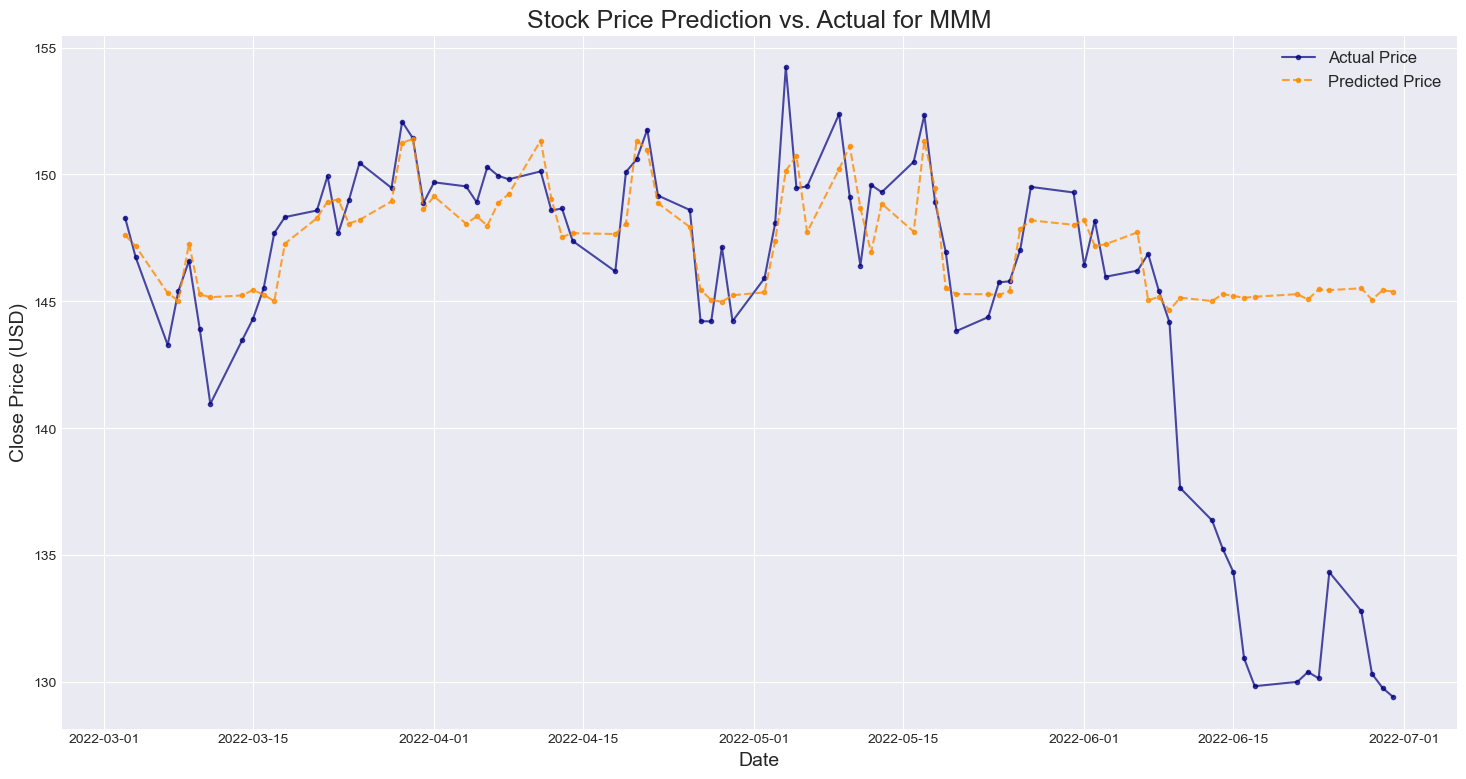

In [40]:
plt.figure(figsize=(18, 9))
plt.plot(date_test, y_test.values, label='Actual Price', color='navy', marker='.', alpha=0.7)
plt.plot(date_test, y_pred, label='Predicted Price', color='darkorange', linestyle='--', marker='.', alpha=0.8)
plt.title(f'Stock Price Prediction vs. Actual for {df_stock["Symbol"].iloc[0]}', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price (USD)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

/var/folders/g8/904gd6rj7q38swgfdjrtm72m0000gn/T/ipykernel_73847/3005661857.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


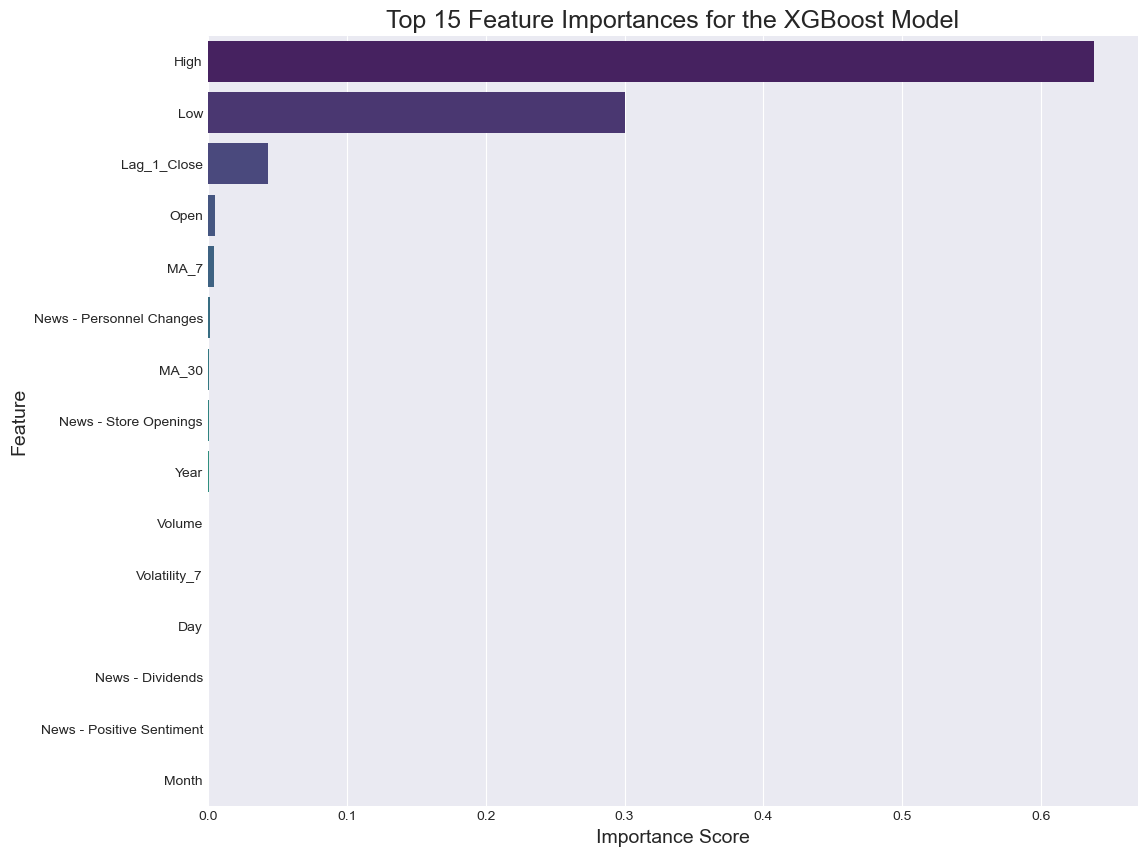

In [41]:
feature_importance = pd.DataFrame({'feature': features, 'importance': xgb_regressor.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(15) # Top 15 features

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Top 15 Feature Importances for the XGBoost Model', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.show()